## HW3 Code ##

#### Packages

In [ ]:
#%pip install pandas scikit-learn numpy matplotlib
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import  r2_score
import matplotlib.pyplot as plt

#### Loading Data: Using X1, X2, X3 as predictors for the output Y

In [104]:

data = pd.read_csv("HW03_data.csv")
X, Y = data[['X1', 'X2', 'X3']], data['Y']
Y = Y.values.reshape(-1, 1) # Reshape for downstream use


#### Data splitting for 50/20/30 train/val/test

In [105]:
print(X.shape, Y.shape) # Check shapes of X and Y

X_train, X_val, Y_train, Y_val= train_test_split(X, Y, test_size=0.2, random_state=42) # Training and Validation split (80/20)

# 500 * 0.8 = 400 for training, 500 * 0.2 = 100 for validation
# 400 * 0.375 = 150 for test, 400 * 0.625 = 250 for training
# 50% training, 20% validation, 30% test split from 500 is 250 training, 100 validation, 150 test
X_train, X_test, Y_train, Y_test = train_test_split(X_train, Y_train, test_size=0.375, random_state=42) # Training and Test Split again for (50/20/30)

print("\n====Data Split====")
print("Training set (50%):", X_train.shape, Y_train.shape) # Check shapes of training data
print("Validation set (20%):", X_val.shape, Y_val.shape) # Check shapes of validation data
print("Test set (30%):", X_test.shape, Y_test.shape) # Check shapes of test data

(500, 3) (500, 1)

====Data Split====
Training set (50%): (250, 3) (250, 1)
Validation set (20%): (100, 3) (100, 1)
Test set (30%): (150, 3) (150, 1)


#### Standarization of data

In [106]:
scaler = StandardScaler() # Fit scaler on training data
X_train = scaler.fit_transform(X_train) # Fit and transform training data
X_val = scaler.transform(X_val) # Transform validation data
X_test = scaler.transform(X_test) # Transform test data


#### Training KNN Regressor and finding optimal K

In [107]:
best_k = None
best_r2 = -float('inf')
r2_scores = []

for k in range(1, 16):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_val_pred = knn.predict(X_val)
    y_test_pred = knn.predict(X_test)
    y_train_pred = knn.predict(X_train)
    r2_train = r2_score(Y_train, y_train_pred)
    r2_val = r2_score(Y_val, y_val_pred)
    r2_test = r2_score(Y_test, y_test_pred)
    r2_scores.append((k, r2_train, r2_val,r2_test))
    if r2_val > best_r2:
        best_r2 = r2_val
        best_k = k
results_df = pd.DataFrame(r2_scores, columns=['K', 'R^2 Train', 'R^2 Validation', 'R^2 Test'])
print("Best K (validation set):", best_k)
print("Best R^2 on validation set:", best_r2)
for k, r2_train, r2_val, r2_test in r2_scores:
    print(f"K={k}: R^2 on test set = {r2_test:.4f}")

Best K (validation set): 5
Best R^2 on validation set: 0.715830548172002
K=1: R^2 on test set = 0.6443
K=2: R^2 on test set = 0.7204
K=3: R^2 on test set = 0.7343
K=4: R^2 on test set = 0.7390
K=5: R^2 on test set = 0.7175
K=6: R^2 on test set = 0.7027
K=7: R^2 on test set = 0.6919
K=8: R^2 on test set = 0.6567
K=9: R^2 on test set = 0.6493
K=10: R^2 on test set = 0.6437
K=11: R^2 on test set = 0.6342
K=12: R^2 on test set = 0.6229
K=13: R^2 on test set = 0.5987
K=14: R^2 on test set = 0.5837
K=15: R^2 on test set = 0.5687


#### Table and Plot of R^2 Score for Train, Val, and Test

Table

In [108]:
print("\n====R^2 Scores for K=1 to 15====")
print(results_df)


====R^2 Scores for K=1 to 15====
     K  R^2 Train  R^2 Validation  R^2 Test
0    1   1.000000        0.600257  0.644254
1    2   0.896969        0.702868  0.720414
2    3   0.866707        0.694269  0.734280
3    4   0.840770        0.702921  0.739007
4    5   0.840457        0.715831  0.717467
5    6   0.811066        0.701440  0.702668
6    7   0.793847        0.694601  0.691904
7    8   0.787908        0.678408  0.656656
8    9   0.769049        0.691797  0.649328
9   10   0.752338        0.684485  0.643712
10  11   0.733712        0.681662  0.634182
11  12   0.723468        0.673014  0.622918
12  13   0.707985        0.661187  0.598688
13  14   0.693134        0.651491  0.583700
14  15   0.681376        0.635325  0.568710


Plotting

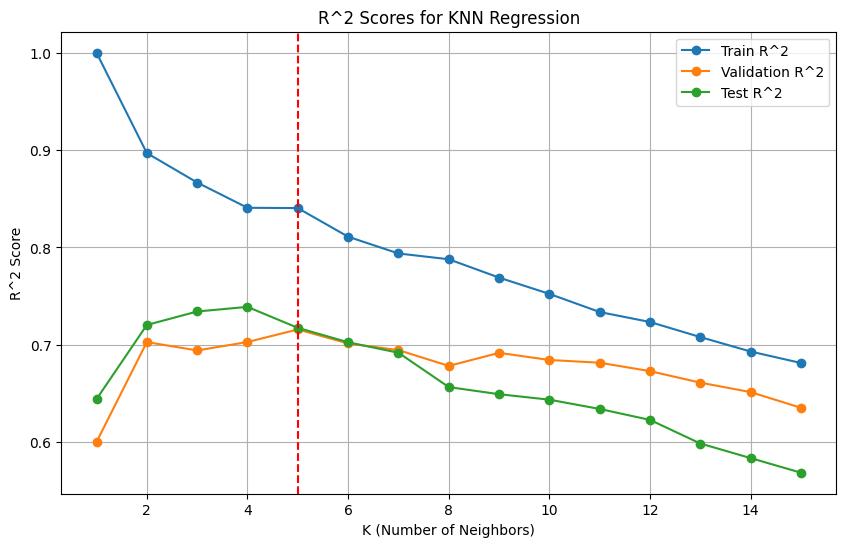

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['R^2 Train'], marker='o', label='Train R^2')
plt.plot(results_df['K'], results_df['R^2 Validation'], marker='o', label='Validation R^2')
plt.plot(results_df['K'], results_df['R^2 Test'], marker='o', label='Test R^2')
plt.title('R^2 Scores for KNN Regression')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('R^2 Score')
plt.legend()
plt.grid()
best_row = results_df.loc[results_df['R^2 Validation'].idxmax()]
best_k = best_row['K']
plt.axvline(x=best_k, color='red', linestyle='--')
plt.savefig("Figure_HW3_42.png", dpi=400)